In [5]:
import numpy as np
import time
import matplotlib as mpl
import matplotlib.pyplot as plt
from DESolver import DESolver

from problems_ODEs import ProblemsODE
from problems_PDEs import ProblemsPDE

import pickle
import os

import seaborn as sns
sns.set_context("talk", font_scale=1.) # "talk"
TEND=0.1
KAPPA=np.asarray([1e+03,2e+03])
#KAPPA=np.asarray([1e-01,2e-01])
#KAPPA=np.asarray([0.,0.])
pde_problem_setup_base={'mx':200,
                        'n':2,
                        'Flux':'linear-advection',
                        'Flux_c':1.,
                        'BC':'periodic',
                        'x_min':0.,
                        'x_max':1.,
                        'kappa':KAPPA, 
                        'IC':'Test1',
                        's':np.asarray([0,1]),
                        'alpha':np.asarray([1,0]),
                        'alpha_i':np.asarray([0,5]),
                        'Flux_name':'FVStagVanLeer-k=1/3'}

#'alpha_i':np.asarray([1,1]),

#'1stOrderUpwindFV'
#'3rdOrderUpwindFD'
#'FVStagVanLeer-k=1'
#'FVStagVanLeer-k=1/3'
#                        '

CFL = 10.0
RHS function did not provide a Jacobian, skipping checks for this function
Computing the Jacobian for RHS_I function
=============RHS_I===========================
Norm of the coded Jacobian: 51747.24898753341
Norm of the finite difference Jacobian: 51747.2491439008
Norm of the difference: 0.00042471423001524256
Maximum difference value position: (384, 384) out of (400, 400) with a value of 7.32688931748271e-05


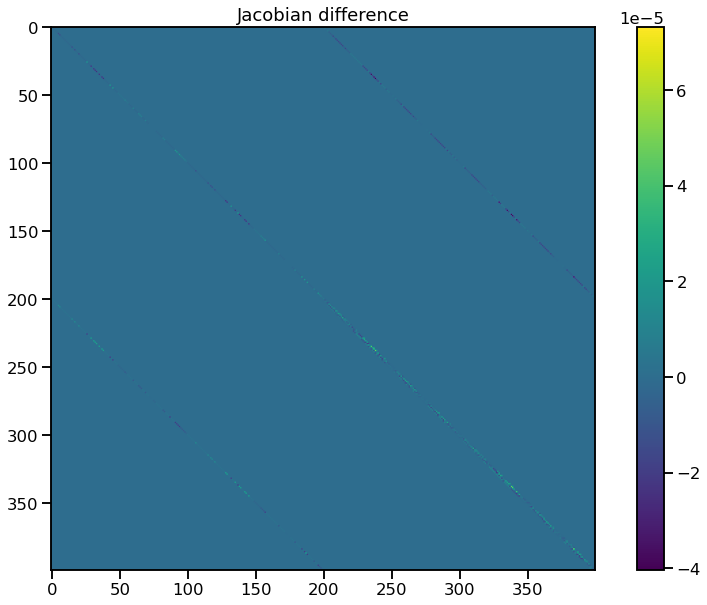

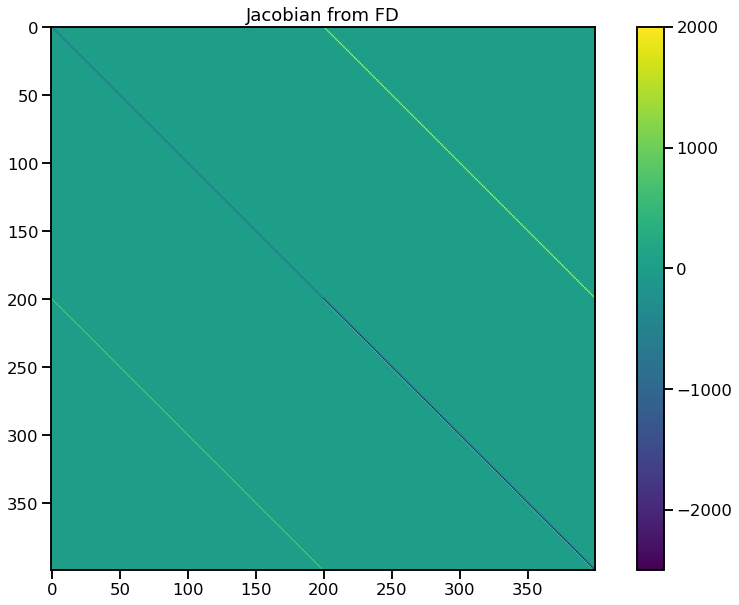

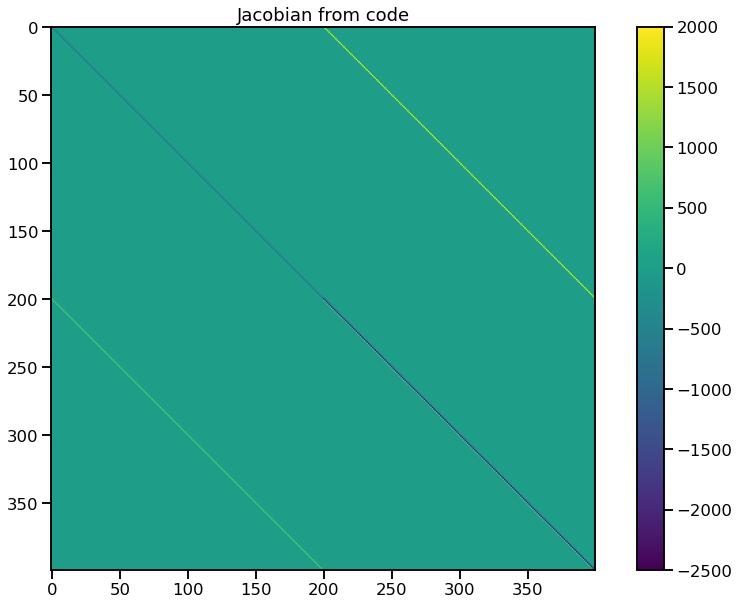

In [6]:
solver=DESolver()
solver.set_info(0)

pde_problem_setup=pde_problem_setup_base.copy()

rhs_e, rhs_i, u_ini, problem_setup, problem= ProblemsPDE('Advection Reaction 1D',pde_problem_setup)#('Navier-Stokes2D')

solver.setup(keep_history=True)
solver.set_function_context(problem_setup['context'])
solver.set_initial_solution(u_ini)

#solver.set_method('RK4')
solver.set_method('ARK2e')
#solver.set_method('ARK-IMEX-MR4')
#solver.set_method('ARK-IMEX-Mix-1-1')


if(rhs_i is not None):
    solver.set_rhs({'imex_explicit':rhs_e,'imex_implicit':rhs_i})
else:
    solver.set_rhs(rhs_e)
    
problem_setup['DT']=0.05    
problem_setup['T_DURATION']['end']=TEND


print("CFL = {:}".format(pde_problem_setup['Flux_c']*problem_setup['DT']/problem_setup['context']['dx']))
mass_ini=problem.TotalMass(problem.unvectorize(u_ini,problem_setup['context']))
solver.set_duration(t_start=problem_setup['T_DURATION']['start'],
                    t_end=problem_setup['T_DURATION']['end'],
                    dt=problem_setup['DT'])

jac_diff,jac,jac_fd=solver.test_Jacobians()
 
fig = plt.figure(figsize=(15, 10))
cs = plt.imshow(jac_diff)#, levels=[10, 30, 50],
##colors=['#808080', '#A0A0A0', '#C0C0C0'], extend='both')
##cs.cmap.set_over('red')
##cs.cmap.set_under('blue')
##cs.changed()
plt.colorbar()
plt.title('Jacobian difference')
plt.show()


fig = plt.figure(figsize=(15, 10))
cs = plt.imshow(jac_fd)#, levels=[10, 30, 50],
#colors=['#808080', '#A0A0A0', '#C0C0C0'], extend='both')
#cs.cmap.set_over('red')
#cs.cmap.set_under('blue')
#cs.changed()
plt.colorbar()
plt.title('Jacobian from FD')
plt.show()

fig = plt.figure(figsize=(15, 10))
plt.imshow(jac)#, levels=[10, 30, 50],
#colors=['#808080', '#A0A0A0', '#C0C0C0'], extend='both')
#cs.cmap.set_over('red')
#cs.cmap.set_under('blue')
#cs.changed()
plt.colorbar()
plt.title('Jacobian from code')
plt.show()